In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# Load excel file
file = "EastWestAirlines.xlsx"

# Check sheet names
print(pd.ExcelFile(file).sheet_names)

# Load DATA sheet 
df = pd.read_excel(file, sheet_name=1)

['Description', 'data']


In [3]:
print(df.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


In [4]:
print(df.shape)

(3999, 12)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None


In [6]:
print(df.describe())

               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.360133e+04    144.114529     2.059515     1.014504   
std    1160.764358  1.007757e+05    773.663804     1.376919     0.147650   
min       1.000000  0.000000e+00      0.000000     1.000000     1.000000   
25%    1010.500000  1.852750e+04      0.000000     1.000000     1.000000   
50%    2016.000000  4.309700e+04      0.000000     1.000000     1.000000   
75%    3020.500000  9.240400e+04      0.000000     3.000000     1.000000   
max    4021.000000  1.704838e+06  11148.000000     5.000000     3.000000   

         cc3_miles    Bonus_miles  Bonus_trans  Flight_miles_12mo  \
count  3999.000000    3999.000000   3999.00000        3999.000000   
mean      1.012253   17144.846212     11.60190         460.055764   
std       0.195241   24150.967826      9.60381        1400.209171   
min       1.000000       0.000000      

In [7]:
# Check missing values
print(df.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [8]:
# Usually ID column 
df = df.drop(columns=['ID#'], errors='ignore')
print(df.head())

   Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    28143           0          1          1          1          174   
1    19244           0          1          1          1          215   
2    41354           0          1          1          1         4123   
3    14776           0          1          1          1          500   
4    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  


In [9]:
#Stander_Scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
print("Scaling done ")

Scaling done 


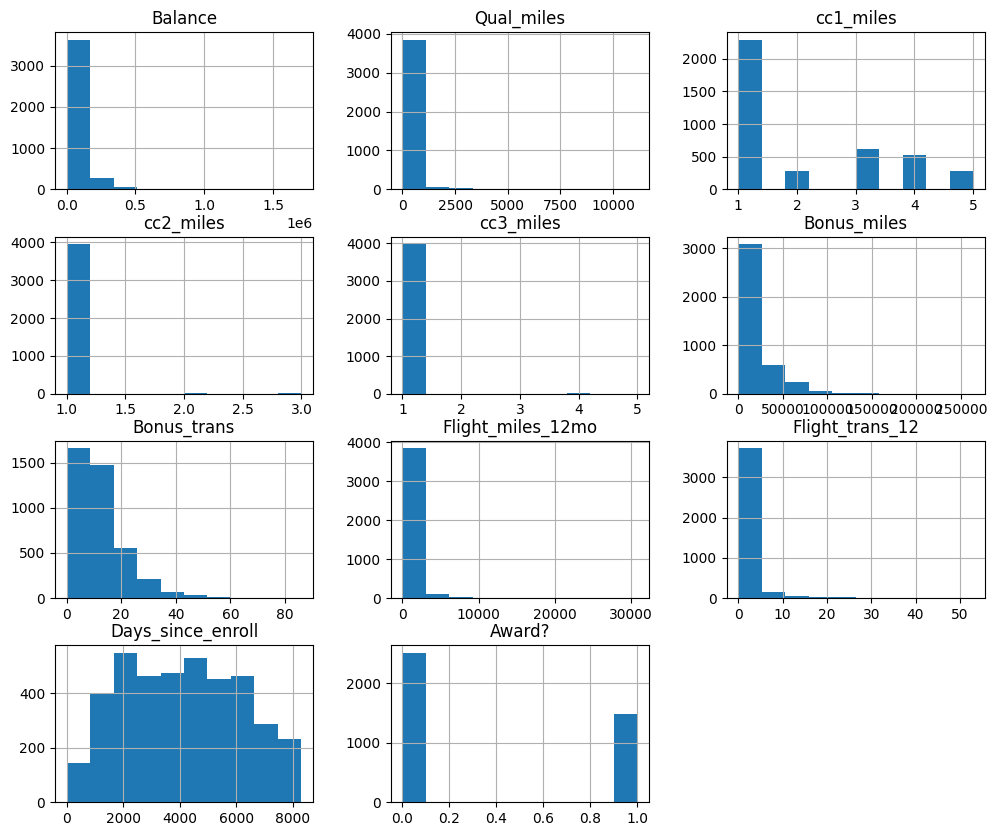

In [10]:
# Histogram
df.hist(figsize=(12,10))
plt.show()

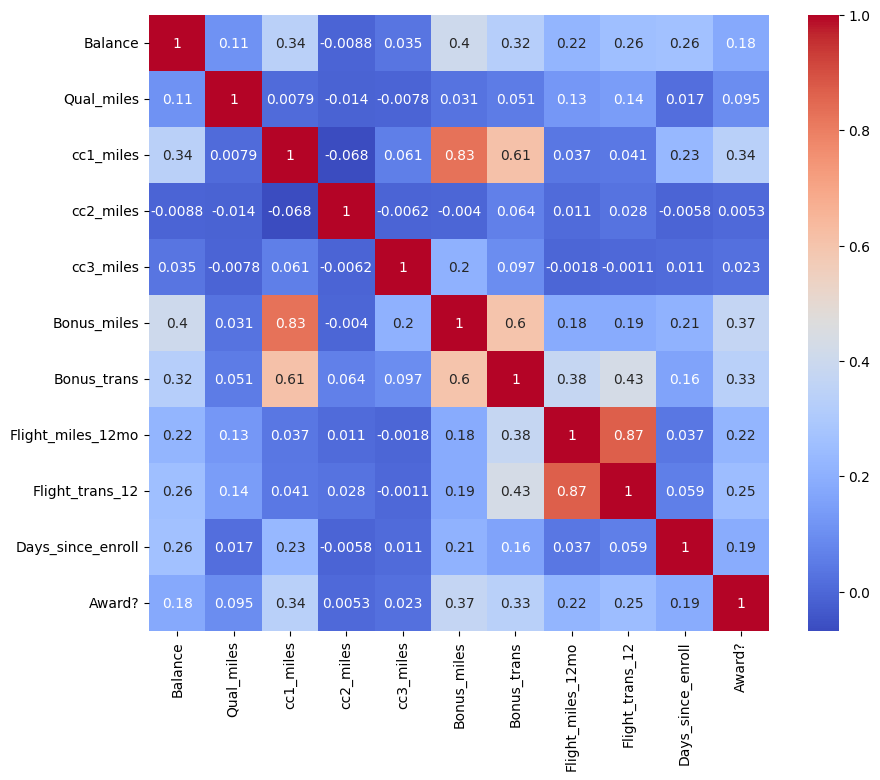

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

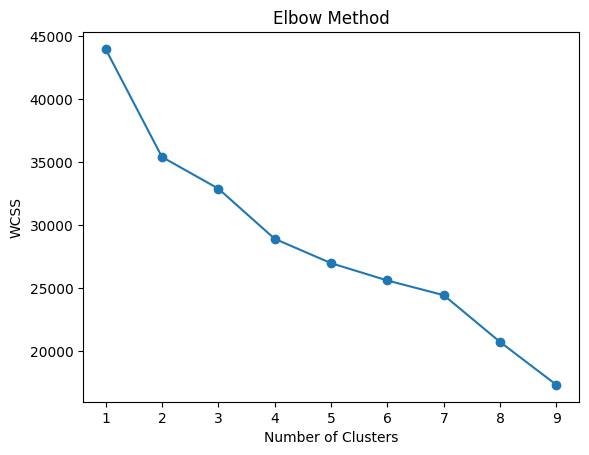

In [12]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [13]:
#K-means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

df['KMeans_Cluster'] = kmeans_labels

In [14]:
score_kmeans = silhouette_score(df_scaled, kmeans_labels)
print("K-Means Silhouette Score:", score_kmeans)

K-Means Silhouette Score: 0.19071186813310886


In [15]:
#DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(df_scaled)

df['DBSCAN_Cluster'] = db_labels

In [16]:
# Remove noise (-1)
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    score_dbscan = silhouette_score(df_scaled[mask], db_labels[mask])
    print("DBSCAN Silhouette Score:", score_dbscan)
else:
    print("DBSCAN: Not enough clusters for silhouette score")

DBSCAN Silhouette Score: 0.29403795451062353


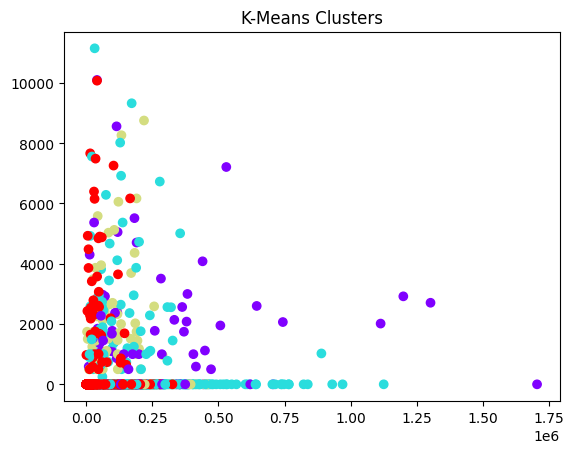

In [17]:
# Use 2 columns for visualization
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=kmeans_labels, cmap='rainbow')
plt.title("K-Means Clusters")
plt.show()

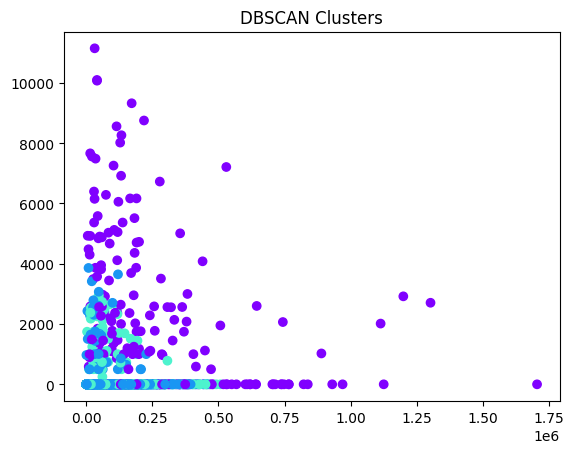

In [18]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=db_labels, cmap='rainbow')
plt.title("DBSCAN Clusters")
plt.show()

In [19]:
print("K-Means Cluster Summary:")
print(df.groupby('KMeans_Cluster').mean())

K-Means Cluster Summary:
                      Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                               
0               193291.147436  795.455128   2.179487   1.038462   1.000000   
1               122119.899548  151.724887   3.885068   1.002715   1.043439   
2                59693.586570  112.733010   1.372168   1.031553   1.000809   
3                36920.458056   96.690413   1.269640   1.006658   1.000000   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0               32292.288462    27.628205        5530.230769        16.211538   
1               43772.394570    19.398190         366.520362         1.087783   
2                6311.116505     8.456311         258.830097         0.806634   
3                4897.208389     6.790280         167.861518         0.509321   

                Day

In [20]:
print("\nDBSCAN Cluster Summary:")
print(df.groupby('DBSCAN_Cluster').mean())


DBSCAN Cluster Summary:
                      Balance   Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
DBSCAN_Cluster                                                                
-1              215733.335484  1381.900000   2.764516   1.070968   1.158065   
 0               56525.714641    29.252178   1.684363   1.000000   1.000000   
 1               72115.619200    61.918400   2.632000   1.000000   1.000000   
 2               38556.733333     0.000000   1.000000   2.000000   1.000000   
 3               36524.250000     0.000000   1.000000   3.000000   1.000000   
 4               31161.600000     0.000000   1.000000   2.000000   1.000000   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
DBSCAN_Cluster                                                                  
-1              45721.603226    25.261290        2994.580645         8.758065   
 0               9589.272501     8.728743         173.045209         0.512650   
 1              24